## Setup & Imports

In [3]:
# IMPORTS

# Core
import os
from pathlib import Path
import gc

# Data
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.font_manager import FontProperties
import seaborn as sns
import plotly.graph_objects as go
from mplsoccer import PyPizza

# Stats
from scipy.stats import rankdata

import pandas as pd
import unicodedata
import re

# PLOT STYLING
sns.set(style="whitegrid", font_scale=1.2)
sns.set_context("talk")

## Load Data

In [ ]:
# Load Matches & Teams

matches = pd.read_parquet("Datasets/SkillCorner Premier League 24-25 data/matches_clean.parquet")

team_lookup = pd.concat([
    matches[["home_team_id","home_team_name"]].rename(columns={"home_team_id":"team_id","home_team_name":"team_name"}),
    matches[["away_team_id","away_team_name"]].rename(columns={"away_team_id":"team_id","away_team_name":"team_name"})
]).drop_duplicates()


# Load Events Data

folder = Path("Datasets/SkillCorner Premier League 24-25 data/dynamic_events_pl_24/dynamic")
dfs = [pd.read_parquet(file) for file in folder.glob("*.parquet")]
events = pd.concat(dfs, ignore_index=True)

print(f"Total events: {len(events)}, Unique matches: {events['match_id'].nunique()}")
print(events["event_type"].value_counts().head(10))


# Load Player Match Data

players_match = pd.read_parquet("Datasets/SkillCorner Premier League 24-25 data/players_match.parquet")

players_match = players_match.rename(columns={
    "id": "player_id",
    "short_name": "player_name",
    "player_role_acronym": "position",
    "player_role_position_group": "position_group"
})

In [189]:
# Load xG and other stats from Understat
stats_understat = pd.read_csv("Datasets/league-players_understat.csv", sep=";")
stats_understat.head()
# https://understat.com/league/EPL/2024

,number,player,team,apps,min,goals,a,xG,xA,xG90,xA90
0,1,Mohamed Salah,Liverpool,38,3392,29,18,27.71,15.86,0.74,0.42
1,2,Alexander Isak,Newcastle United,34,2822,23,6,22.36,5.45,0.71,0.17
2,3,Erling Haaland,Manchester City,31,2749,22,3,23.95,3.58,0.78,0.12
3,4,Chris Wood,Nottingham Forest,36,3024,20,3,15.64,3.04,0.47,0.09
4,5,Bryan Mbeumo,Brentford,38,3419,20,7,13.63,10.38,0.36,0.27


# Minutes Summary & Main Position

In [ ]:

# Minutes Summary

minutes_summary = (
    players_match.groupby(["player_id","player_name"])
    .agg(
        minutes_tip=("playing_time_total_minutes_tip","sum"),
        minutes_otip=("playing_time_total_minutes_otip","sum"),
        minutes_played=("playing_time_total_minutes_played","sum")
    )
    .reset_index()
)


# Determine Main Position

position_minutes = (
    players_match.groupby(["player_id","player_name","position","position_group"], as_index=False)
    .agg(minutes_played=("playing_time_total_minutes_played","sum"))
)
position_minutes_sorted = position_minutes.sort_values(["player_id","minutes_played"], ascending=[True,False])

def get_main_position(df):
    main_pos = df.iloc[0]["position"]
    pos_group = df.iloc[0]["position_group"]

    if main_pos == "SUB" and len(df) > 1:
        main_pos = df.iloc[1]["position"]
        pos_group = df.iloc[1]["position_group"]

    if main_pos == "GK":
        pos_group = "Goalkeeper"

    return pd.Series({"main_position": main_pos, "position_group": pos_group})

main_positions = position_minutes_sorted.groupby("player_id", group_keys=False).apply(get_main_position).reset_index()

# Merge final player dataset
players = minutes_summary.merge(main_positions, on="player_id", how="left")
players["minutes_played"] = players["minutes_played"].replace(0, np.nan)

In [ ]:
players.head()

# Passing Options & Decision Metrics

In [ ]:
=========
# PASSING OPTIONS PREP
=========
passing_options = events[events["event_type"] == "passing_option"].copy()

passing_options = passing_options.rename(columns={
    "player_in_possession_id": "passer_id",
    "player_in_possession_name": "passer_name",
    "player_id": "receiver_id",
    "player_name": "receiver_name"
})

passing_options["pass_value"] = (
    passing_options["xthreat"] * passing_options["xpass_completion"]
)

=========
# BEST OPTION PER POSSESSION
=========
best_option = (
    passing_options.groupby(
        ["match_id", "associated_player_possession_event_id"], as_index=False
    )
    .agg(best_pass_value=("pass_value", "max"))
)

passing_options = passing_options.merge(
    best_option,
    on=["match_id", "associated_player_possession_event_id"],
    how="left"
)

=========
# KEEP POSSESSIONS WITH >1 OPTION
=========
option_counts = (
    passing_options.groupby(
        ["match_id", "associated_player_possession_event_id"]
    )
    .size()
    .reset_index(name="n_options")
)

passing_options = passing_options.merge(
    option_counts,
    on=["match_id", "associated_player_possession_event_id"],
    how="left"
)

passing_options = passing_options[passing_options["n_options"] > 1]

=========
# CHOSEN PASSES
=========
chosen_passes = passing_options[passing_options["targeted"] == True].copy()

chosen_passes["decision_quality"] = (
    chosen_passes["pass_value"] /
    chosen_passes["best_pass_value"].replace(0, np.nan)
)

chosen_passes["chose_best"] = (
    chosen_passes["pass_value"] >= chosen_passes["best_pass_value"] * 0.95
)

chosen_passes["actual_completion"] = (
    (chosen_passes["received"] == True).astype(int)
)

chosen_passes["completion_minus_xpass"] = (
    chosen_passes["actual_completion"] - chosen_passes["xpass_completion"]
)

=========
# 🧠 TEAM INFO (FROM EVENTS - CONSISTENT)
=========
player_team_minutes = (
    events.groupby(["player_id", "team_shortname"], as_index=False)
    .agg(minutes_played=("match_id", "count"))  # proxy for involvement
)

player_team_minutes = player_team_minutes.sort_values(
    ["player_id", "minutes_played"],
    ascending=[True, False]
)

player_team_minutes["team_rank"] = (
    player_team_minutes.groupby("player_id").cumcount() + 1
)

# Main team
main_team = player_team_minutes[player_team_minutes["team_rank"] == 1][
    ["player_id", "team_shortname"]
].rename(columns={"team_shortname": "main_team"})

# Second team
second_team = player_team_minutes[player_team_minutes["team_rank"] == 2][
    ["player_id", "team_shortname"]
].rename(columns={"team_shortname": "second_team"})

# Combine
team_info = main_team.merge(second_team, on="player_id", how="left")
team_info["multi_team"] = team_info["second_team"].notna()

=========
# PASSER METRICS (FINAL)
=========
passer_metrics = (
    chosen_passes.groupby(["passer_id", "passer_name"])
    .agg(
        passes_attempted=("pass_value", "count"),
        avg_decision_quality=("decision_quality", "mean"),
        chose_best_rate=("chose_best", "mean"),
        chose_best_count=("chose_best", "sum"),
        chose_not_best_count=("chose_best", lambda x: (~x).sum()),
        completion_minus_xpass_per_pass=("completion_minus_xpass", "mean"),
        completion_minus_xpass_total=("completion_minus_xpass", "sum"),
        total_pass_value=("pass_value", "sum"),
        avg_pass_value=("pass_value", "mean"),
        avg_xthreat=("xthreat", "mean"),
        avg_xpass_completion=("xpass_completion", "mean")
    )
    .reset_index()
    .merge(players, left_on="passer_id", right_on="player_id", how="left")
    .merge(team_info, left_on="passer_id", right_on="player_id", how="left")
    .drop(columns=["player_id"], errors="ignore")
)

=========
# RECEIVER METRICS (FINAL)
=========
receiver_metrics = (
    passing_options.groupby(["receiver_id", "receiver_name"])
    .agg(
        passing_options_available=("receiver_id", "count"),
        times_targeted=("targeted", "sum"),
        option_selection_rate=("targeted", "mean"),
        total_option_value=("pass_value", "sum"),
        avg_option_value=("pass_value", "mean"),
        total_xthreat_available=("xthreat", "sum"),
        avg_xthreat_available=("xthreat", "mean"),
        avg_xpass_passing_option_created=("xpass_completion", "mean")
    )
    .reset_index()
    .merge(players, left_on="receiver_id", right_on="player_id", how="left")
    .merge(team_info, left_on="receiver_id", right_on="player_id", how="left")
    .drop(columns=["player_id"], errors="ignore")
)

## Off-Ball Run Metrics

In [ ]:
off_ball_runs = events[events["event_type"] == "off_ball_run"].copy()
off_ball_runs = off_ball_runs.dropna(axis=1, how='all')

player_offball_metrics = (
    off_ball_runs.groupby(["player_id", "player_name"])
    .agg(
        offball_runs_total=("event_id", "count"),
        offball_distance_total=("distance_covered", "sum"),
        offball_distance_avg=("distance_covered", "mean"),
        offball_speed_avg=("speed_avg", "mean")
    )
    .reset_index()
).merge(players[['player_id', 'minutes_played']], on='player_id', how='left')

## On-ball Engagement

In [ ]:
on_ball_engagement = events[events["event_type"] == "on_ball_engagement"].copy()

# Drop columns that are all NaN
on_ball_engagement = on_ball_engagement.dropna(axis=1, how='all')

pd.set_option('display.max_columns', None)  # ensure all columns are visible
on_ball_engagement.head()

In [ ]:
on_ball_engagement["end_type"].value_counts()

In [ ]:
# OBE metrics aggregation
player_onball_metrics = (
    on_ball_engagement.groupby(["player_id", "player_name"])
    .agg(
        # Overall engagement
        obe_total_events=("event_id", "count"),
        obe_distance_total=("distance_covered", "sum"),
        obe_distance_avg=("distance_covered", "mean"),
        obe_speed_avg=("speed_avg", "mean"),
        
        # Line-breaking actions
        obe_linebreaks_affected=("affected_line_break", lambda x: x.notna().sum()),
        obe_linebreaks_attempted=("affected_line_breaking_passing_option_attempted", lambda x: x.eq(True).sum()),
        obe_linebreaks_xthreat=("affected_line_breaking_passing_option_xthreat", "sum"),
        obe_linebreaks_dangerous=("affected_line_breaking_passing_option_dangerous", lambda x: x.eq(True).sum()),

        # Pressing chain metrics
        obe_pressing_chains_total=("pressing_chain", lambda x: x.eq(True).sum()),
        obe_pressing_chain_length_avg=("pressing_chain_length", "mean"),
        obe_pressing_chain_direct_regain=("pressing_chain_end_type", lambda x: (x=="direct_regain").sum()),
        obe_pressing_chain_indirect_regain=("pressing_chain_end_type", lambda x: (x=="indirect_regain").sum()),
        obe_pressing_chain_direct_disruption=("pressing_chain_end_type", lambda x: (x=="direct_disruption").sum()),
        obe_pressing_chain_indirect_disruption=("pressing_chain_end_type", lambda x: (x=="indirect_disruption").sum()),
        obe_pressing_chain_foul=("pressing_chain_end_type", lambda x: (x=="foul_committed").sum()),

        # Defensive effect metrics
        obe_possession_losses_forced=("stop_possession_danger", "sum"),
        obe_beaten_by_possession=("beaten_by_possession", "sum"),
        obe_reduce_possession_danger=("reduce_possession_danger", "sum"),
        
        # Engagement type counts (optional, if you want to see which OBE type they do)
        obe_pressing_events=("event_subtype", lambda x: (x=="pressing").sum()),
        obe_pressure_events=("event_subtype", lambda x: (x=="pressure").sum()),
        obe_other_events=("event_subtype", lambda x: (x=="other").sum())
    )
    .reset_index()
)

player_onball_metrics.head()

# Shots

In [ ]:
possession = events[events["event_type"] == "player_possession"].copy()

In [ ]:
# Drop columns that are all NaN
possession = possession.dropna(axis=1, how='all')

pd.set_option('display.max_columns', None)  # ensure all columns are visible
possession.head()

In [ ]:
possession["end_type"].value_counts()

In [ ]:
shots = possession[possession["end_type"] == "shot"].copy()

In [ ]:

# 1. PREP FEATURES (distance + angle)


GOAL_X = 52.5
GOAL_Y = 0
GOAL_WIDTH = 7.32

# Shot distance
possession["shot_distance"] = np.sqrt(
    (GOAL_X - possession["x_end"])**2 +
    (GOAL_Y - possession["y_end"])**2
)

# Shot angle
possession["shot_angle"] = np.arctan2(
    GOAL_WIDTH * (GOAL_X - possession["x_end"]),
    (GOAL_X - possession["x_end"])**2 +
    (possession["y_end"])**2 -
    (GOAL_WIDTH / 2)**2
)


# 2. PLAYER SHOT METRICS AGGREGATION


player_shot_metrics = (
    possession.groupby(["player_id", "player_name"])
    .agg(
        # 🔢 Volume & output
        shots_total=("event_id", "count"),
        shots_goals=("lead_to_goal", "sum"),
        shots_conversion=("lead_to_goal", "mean"),

        # 📍 Location
        shots_avg_distance=("shot_distance", "mean"),
        shots_median_distance=("shot_distance", "median"),
        shots_avg_angle=("shot_angle", "mean"),

        shots_pct_inside_box=("penalty_area_end", "mean"),
        shots_pct_central=("channel_end", lambda x: (x == "center").mean()),
        shots_pct_half_space=("channel_end", lambda x: x.str.contains("half_space", na=False).mean()),
        shots_pct_wide=("channel_end", lambda x: x.str.contains("wide", na=False).mean()),

        # ⚡ Speed & transition
        shots_avg_speed=("speed_avg", "mean"),
        shots_pct_hsr=("speed_avg_band", lambda x: (x == "hsr").mean()),
        shots_pct_sprinting=("speed_avg_band", lambda x: (x == "sprinting").mean()),

        shots_pct_forward_momentum=("forward_momentum", "mean"),
        shots_pct_carry=("carry", "mean"),

        # 🧱 Pressure
        shots_avg_opponents_ahead=("n_opponents_ahead_end", "mean"),
        shots_avg_opponents_bypassed=("n_opponents_bypassed", "mean"),
        shots_avg_opponents_overtaken=("n_opponents_overtaken", "mean"),

        shots_pct_vs_low_block=("team_out_of_possession_phase_type", lambda x: (x == "low_block").mean()),
        shots_pct_vs_high_block=("team_out_of_possession_phase_type", lambda x: (x == "high_block").mean()),
        shots_pct_vs_transition=("team_out_of_possession_phase_type", lambda x: x.str.contains("transition", na=False).mean()),

        # 📐 Separation
        shots_avg_separation=("separation_end", "mean"),
        shots_avg_separation_gain=("separation_gain", "mean"),
        shots_pct_inside_def_shape=("inside_defensive_shape_end", "mean"),

        # 🧠 Finishing style
        shots_pct_one_touch=("one_touch", "mean"),
        shots_pct_headers=("is_header", "mean"),

        shots_pct_after_quick_pass=("quick_pass", "mean"),
        shots_pct_give_and_go=("initiate_give_and_go", "mean"),

        # 🔗 Build-up
        shots_pct_after_pass_reception=("start_type", lambda x: (x == "pass_reception").mean()),
        shots_pct_after_recovery=("start_type", lambda x: (x == "recovery").mean()),
        shots_pct_after_set_piece=("start_type", lambda x: x.str.contains("corner|free_kick", na=False).mean()),

        shots_avg_pass_length_before=("pass_distance_received", "mean"),
        shots_pct_long_pass_assist=("pass_range_received", lambda x: (x == "long").mean()),

        # 🧩 Phase
        shots_pct_finish_phase=("team_in_possession_phase_type", lambda x: (x == "finish").mean()),
        shots_pct_transition_phase=("team_in_possession_phase_type", lambda x: x.str.contains("transition", na=False).mean()),
        shots_pct_build_up_phase=("team_in_possession_phase_type", lambda x: (x == "build_up").mean()),

        shots_pct_first_in_phase=("first_player_possession_in_team_possession", "mean"),
        shots_pct_last_in_phase=("last_player_possession_in_team_possession", "mean"),

        # 🎯 Decision context
        shots_avg_passing_options=("n_passing_options", "mean"),
        shots_avg_passing_options_ahead=("n_passing_options_ahead", "mean"),

        # 🧬 Defensive line
        shots_avg_delta_def_line_end=("delta_to_last_defensive_line_end", "mean"),
        shots_avg_delta_def_line_gain=("delta_to_last_defensive_line_gain", "mean"),

        # 🧭 Direction
        shots_pct_forward_direction=("trajectory_direction", lambda x: (x == "forward").mean()),
        shots_pct_cut_inside=("in_to_out", "mean"),

        # 🧱 Defensive structure
        shots_pct_vs_organised_defense=("organised_defense", "mean"),
        shots_avg_defensive_lines=("n_defensive_lines", "mean"),
    )
    .reset_index()
)


# 3. ADD METRICS REQUIRING MULTIPLE COLUMNS


# Dangerous passing options (needs both columns)
player_shot_metrics["shots_avg_dangerous_options"] = (
    possession["n_passing_options_dangerous_difficult"].fillna(0)
    + possession["n_passing_options_dangerous_not_difficult"].fillna(0)
).groupby(possession["player_id"]).mean().values


# 4. COMPOSITE METRICS


# Pressure index
player_shot_metrics["shots_pressure_index"] = (
    player_shot_metrics["shots_avg_opponents_ahead"]
    - player_shot_metrics["shots_avg_separation"]
)

# Freedom index
player_shot_metrics["shots_freedom_index"] = (
    player_shot_metrics["shots_avg_separation"]
    / (player_shot_metrics["shots_avg_opponents_ahead"] + 1)
)

# Aggressiveness
player_shot_metrics["shots_aggressiveness"] = (
    player_shot_metrics["shots_total"]
    / (player_shot_metrics["shots_total"] + player_shot_metrics["shots_avg_passing_options_ahead"])
)

# Transition tendency
player_shot_metrics["shots_transition_pct"] = (
    player_shot_metrics["shots_pct_forward_momentum"]
)

# Self-created shots
player_shot_metrics["shots_self_created_pct"] = (
    player_shot_metrics["shots_pct_carry"]
    + player_shot_metrics["shots_pct_forward_momentum"]
)

# Shot difficulty index (improved)
player_shot_metrics["shots_difficulty_index"] = (
    player_shot_metrics["shots_avg_distance"]
    + player_shot_metrics["shots_avg_opponents_ahead"]
    - player_shot_metrics["shots_avg_separation"]
)


# DONE


player_shot_metrics.head()

# Other possessions

In [ ]:
possession = events[events["event_type"] == "player_possession"].copy()
possession.head()

In [ ]:
player_possession_metrics = (
    possession.groupby(["player_id", "player_name"])
    .agg(
        # -------------------------
        # VOLUME
        # -------------------------
        possessions_total=("event_id", "count"),

        # -------------------------
        # END TYPE DISTRIBUTION
        # -------------------------
        possessions_ending_shot=("end_type", lambda x: (x == "shot").sum()),
        possessions_ending_pass=("end_type", lambda x: (x == "pass").sum()),
        possessions_ending_loss=("end_type", lambda x: (x == "possession_loss").sum()),
        possessions_ending_foul_suffered=("end_type", lambda x: (x == "foul_suffered").sum()),
        possessions_ending_clearance=("end_type", lambda x: (x == "clearance").sum()),

        # -------------------------
        # EFFICIENCY
        # -------------------------
        possession_shot_rate=("end_type", lambda x: (x == "shot").mean()),
        possession_loss_rate=("end_type", lambda x: (x == "possession_loss").mean()),

        # -------------------------
        # DURATION & DISTANCE
        # -------------------------
        possession_duration_avg=("duration", "mean"),
        possession_duration_total=("duration", "sum"),

        possession_distance_avg=("distance_covered", "mean"),
        possession_distance_total=("distance_covered", "sum"),

        # -------------------------
        # SPEED & INTENSITY
        # -------------------------
        possession_speed_avg=("speed_avg", "mean"),
        possession_high_speed_actions=("speed_avg_band", lambda x: x.isin(["hsr", "sprinting"]).sum()),

        # -------------------------
        # PROGRESSION
        # -------------------------
        possession_forward_actions=("forward_momentum", lambda x: x.eq(True).sum()),
        possession_forward_rate=("forward_momentum", lambda x: x.eq(True).mean()),

        possession_progression_avg=("delta_to_last_defensive_line_end", "mean"),
        possession_progression_total=("delta_to_last_defensive_line_end", "sum"),

        # -------------------------
        # DEFENSIVE LINE BREAKING
        # -------------------------
        possession_line_breaks=("n_opponents_bypassed", "sum"),
        possession_line_breaks_avg=("n_opponents_bypassed", "mean"),

        # -------------------------
        # PRESSURE / SPACE
        # -------------------------
        possession_separation_start_avg=("separation_start", "mean"),
        possession_separation_end_avg=("separation_end", "mean"),
        possession_separation_gain_avg=("separation_gain", "mean"),

        # -------------------------
        # POSITIONAL CONTEXT
        # -------------------------
        possession_attacking_third_rate=("third_start", lambda x: (x == "attacking_third").mean()),
        possession_penalty_area_rate=("penalty_area_end", lambda x: x.eq(True).mean()),

        # -------------------------
        # ACTION TYPES
        # -------------------------
        possession_carries=("carry", lambda x: x.eq(True).sum()),
        possession_carry_rate=("carry", lambda x: x.eq(True).mean()),

        possession_one_touch=("one_touch", lambda x: x.eq(True).sum()),
        possession_one_touch_rate=("one_touch", lambda x: x.eq(True).mean()),

        possession_headers=("is_header", lambda x: x.eq(True).sum()),

        # -------------------------
        # PASS CONTEXT
        # -------------------------
        possession_received_pass_avg_distance=("pass_distance_received", "mean"),
        possession_received_pass_forward_rate=("pass_direction_received", lambda x: (x == "forward").mean()),

        # -------------------------
        # TEAM CONTEXT
        # -------------------------
        possession_teammates_ahead_avg=("n_teammates_ahead_end", "mean"),
        possession_opponents_ahead_avg=("n_opponents_ahead_end", "mean"),

        # -------------------------
        # GAME STATE
        # -------------------------
        possession_winning_rate=("game_state", lambda x: (x == "winning").mean()),
        possession_drawing_rate=("game_state", lambda x: (x == "drawing").mean()),
        possession_losing_rate=("game_state", lambda x: (x == "losing").mean()),

        # -------------------------
        # PHASE CONTEXT
        # -------------------------
        possession_finish_phase=("team_in_possession_phase_type", lambda x: (x == "finish").sum()),
        possession_build_up_phase=("team_in_possession_phase_type", lambda x: (x == "build_up").sum()),
        possession_create_phase=("team_in_possession_phase_type", lambda x: (x == "create").sum()),

        # -------------------------
        # DIRECTNESS / STYLE
        # -------------------------
        possession_verticality=("trajectory_angle", "mean"),
    )
    .reset_index()
)

In [ ]:
player_possession_metrics["possession_directness_index"] = (
    player_possession_metrics["possession_distance_total"]
    / player_possession_metrics["possession_duration_total"]
)

player_possession_metrics["possession_threat_index"] = (
    player_possession_metrics["possession_line_breaks"]
    * player_possession_metrics["possession_progression_total"]
)

player_possession_metrics["possession_control_index"] = (
    1 - player_possession_metrics["possession_loss_rate"]
)

player_possession_metrics["possession_end_product_rate"] = (
    player_possession_metrics["possessions_ending_shot"]
    / player_possession_metrics["possessions_total"]
)

In [ ]:
player_possession_metrics.head()

# Merge everything

In [ ]:
=========
# 0. HELPER FUNCTION
=========
def clean_merge(df, id_col, drop_cols):
    return df.drop(columns=drop_cols, errors="ignore").copy()


=========
# 1. CLEAN DATASETS
=========

# --- Passer metrics ---
passer_metrics_clean = clean_merge(
    passer_metrics,
    "passer_id",
    [
        "passer_name", "team_shortname",
        "player_id", "player_name",
        "minutes_played", "main_position", "position_group"
    ]
)

# --- Receiver metrics ---
receiver_metrics_clean = clean_merge(
    receiver_metrics,
    "receiver_id",
    [
        "receiver_name", "team_shortname",
        "player_id", "player_name",
        "minutes_played", "main_position", "position_group"
    ]
)

# --- Other datasets ---
offball_clean = clean_merge(player_offball_metrics, "player_id", ["player_name"])
onball_clean = clean_merge(player_onball_metrics, "player_id", ["player_name"])
shot_clean = clean_merge(player_shot_metrics, "player_id", ["player_name"])
possession_clean = clean_merge(player_possession_metrics, "player_id", ["player_name"])


=========
# 2. MERGE EVERYTHING
=========

player_full = players.copy()

# --- Passer ---
player_full = player_full.merge(
    passer_metrics_clean,
    left_on="player_id",
    right_on="passer_id",
    how="left"
)
player_full = player_full.drop(columns=["passer_id"], errors="ignore")

# --- Receiver ---
player_full = player_full.merge(
    receiver_metrics_clean,
    left_on="player_id",
    right_on="receiver_id",
    how="left"
)
player_full = player_full.drop(columns=["receiver_id"], errors="ignore")

# --- Off-ball ---
player_full = player_full.merge(
    offball_clean,
    on="player_id",
    how="left"
)

# --- On-ball engagement ---
player_full = player_full.merge(
    onball_clean,
    on="player_id",
    how="left"
)

# --- Shooting ---
player_full = player_full.merge(
    shot_clean,
    on="player_id",
    how="left"
)

# --- Possession ---
player_full = player_full.merge(
    possession_clean,
    on="player_id",
    how="left"
)


=========
# 3. FINAL CLEANING
=========

# Remove any accidental duplicate columns
player_full = player_full.loc[:, ~player_full.columns.duplicated()]

# Fill numeric NaNs only (important)
numeric_cols = player_full.select_dtypes(include=[np.number]).columns
player_full[numeric_cols] = player_full[numeric_cols].fillna(0)


=========
# 4. SANITY CHECKS
=========

print("Shape:", player_full.shape)
print("Unique players:", player_full["player_id"].nunique())

# Should match number of rows
assert player_full.shape[0] == player_full["player_id"].nunique(), "❌ Duplicate rows detected!"

In [ ]:
player_full.head()

In [ ]:
=========
# 1. DROP DUPLICATED / USELESS COLUMNS
=========

cols_to_drop = [
    # Duplicate IDs from merges
    "player_id_x_x", "player_id_y_x",
    "player_id_x_y", "player_id_y_y",

    # Duplicate minutes (keep the clean final ones: minutes_tip, minutes_otip, minutes_played)
    "minutes_tip_x", "minutes_tip_y",
    "minutes_otip_x", "minutes_otip_y",
    "minutes_played_x", "minutes_played_y",

    # Team duplicates (we will keep _y version)
    "main_team_x", "second_team_x", "multi_team_x"
]

player_full = player_full.drop(columns=cols_to_drop, errors="ignore")


=========
# 2. RENAME FINAL TEAM COLUMNS
=========

player_full = player_full.rename(columns={
    "main_team_y": "main_team",
    "second_team_y": "second_team",
    "multi_team_y": "multi_team"
})


=========
# 3. ENSURE MINUTES COLUMN IS CLEAN
=========

# If minutes_played is missing but exists elsewhere, recover it
if "minutes_played" not in player_full.columns:
    if "minutes_played_y" in player_full.columns:
        player_full["minutes_played"] = player_full["minutes_played_y"]
    elif "minutes_played_x" in player_full.columns:
        player_full["minutes_played"] = player_full["minutes_played_x"]


=========
# 4. REORDER COLUMNS (PLAYER CORE FIRST)
=========

first_cols = [
    "player_id",
    "player_name",
    "main_position",
    "position_group",
    "minutes_tip",
    "minutes_otip",
    "minutes_played",
    "main_team",
    "second_team",
    "multi_team"
]

# Keep only existing columns (safe)
first_cols = [col for col in first_cols if col in player_full.columns]

remaining_cols = [col for col in player_full.columns if col not in first_cols]

player_full = player_full[first_cols + remaining_cols]


=========
# 5. FINAL SANITY CHECK
=========

print("Shape:", player_full.shape)
print("Unique players:", player_full["player_id"].nunique())

assert player_full.shape[0] == player_full["player_id"].nunique(), "❌ Duplicate rows detected!"

In [ ]:
player_full.head()

In [ ]:
df = player_full.copy()

# Avoid division errors
df["minutes_tip_safe"] = df["minutes_tip"].replace(0, np.nan)
df["minutes_otip_safe"] = df["minutes_otip"].replace(0, np.nan)


=========
# 1. DEFINE COLUMN GROUPS
=========

tip_cols = []
otip_cols = []

for col in df.columns:
    
    # Skip identifiers
    if col in ["player_id", "player_name", "main_position", "position_group",
               "main_team", "second_team", "multi_team",
               "minutes_tip", "minutes_otip"]:
        continue
    
    # Skip already normalised / ratios
    if any(x in col for x in [
        "avg", "rate", "pct", "index", "per", "conversion"
    ]):
        continue
    
    # OTIP metrics (your rule)
    if col.startswith("obe_") or col.startswith("offball_"):
        otip_cols.append(col)
    else:
        tip_cols.append(col)


=========
# 2. APPLY PER 90 NORMALISATION
=========

# TIP per 90
df[tip_cols] = df[tip_cols].div(df["minutes_tip_safe"], axis=0) * 90

# OTIP per 90
df[otip_cols] = df[otip_cols].div(df["minutes_otip_safe"], axis=0) * 90


=========
# 3. CLEANUP
=========

df = df.drop(columns=["minutes_tip_safe", "minutes_otip_safe"])


=========
# 4. OPTIONAL: ADD SUFFIXES (VERY USEFUL)
=========

df = df.rename(columns={
    col: f"{col}_per90" for col in tip_cols + otip_cols
})


=========
# DONE
=========

player_full_per90 = df

In [ ]:
player_full_per90.head()

# Download + Import final dataset

In [ ]:
# File path
file_path = r'Datasets\SkillCorner Premier League 24-25 data\Player Metrics 24-25.pkl'

# Save player_full_per90 as a pickle
player_full_per90.to_pickle(file_path)

print(f"player_full_per90 saved to: {file_path}")

In [ ]:
# Ensure folder exists
os.makedirs(r'Datasets', exist_ok=True)

# File path
csv_path = r'Datasets\SkillCorner Premier League 24-25 data\Player Metrics 24-25.csv'

# Save as CSV
player_full_per90.to_csv(csv_path, index=False)

print(f"player_full_per90 saved as CSV at: {csv_path}")

In [190]:
# To reload later
player_full_per90 = pd.read_pickle(r'Datasets\SkillCorner Premier League 24-25 data\Player Metrics 24-25.pkl')

# Combine with understat data

In [191]:
stats_understat.head()

,number,player,team,apps,min,goals,a,xG,xA,xG90,xA90
0,1,Mohamed Salah,Liverpool,38,3392,29,18,27.71,15.86,0.74,0.42
1,2,Alexander Isak,Newcastle United,34,2822,23,6,22.36,5.45,0.71,0.17
2,3,Erling Haaland,Manchester City,31,2749,22,3,23.95,3.58,0.78,0.12
3,4,Chris Wood,Nottingham Forest,36,3024,20,3,15.64,3.04,0.47,0.09
4,5,Bryan Mbeumo,Brentford,38,3419,20,7,13.63,10.38,0.36,0.27


In [192]:
player_full_per90.head()

,player_id,player_name,main_position,position_group,minutes_tip,minutes_otip,main_team,second_team,multi_team,passes_attempted_per90,avg_decision_quality,chose_best_rate,chose_best_count_per90,chose_not_best_count_per90,completion_minus_xpass_per_pass,completion_minus_xpass_total_per90,total_pass_value_per90,avg_pass_value,avg_xthreat,avg_xpass_completion,passing_options_available_per90,times_targeted_per90,option_selection_rate,total_option_value_per90,avg_option_value,total_xthreat_available_per90,avg_xthreat_available,avg_xpass_passing_option_created,offball_runs_total_per90,offball_distance_total_per90,offball_distance_avg,offball_speed_avg,obe_total_events_per90,obe_distance_total_per90,obe_distance_avg,obe_speed_avg,obe_linebreaks_affected_per90,obe_linebreaks_attempted_per90,obe_linebreaks_xthreat_per90,obe_linebreaks_dangerous_per90,obe_pressing_chains_total_per90,obe_pressing_chain_length_avg,obe_pressing_chain_direct_regain_per90,obe_pressing_chain_indirect_regain_per90,obe_pressing_chain_direct_disruption_per90,obe_pressing_chain_indirect_disruption_per90,obe_pressing_chain_foul_per90,obe_possession_losses_forced_per90,obe_beaten_by_possession_per90,obe_reduce_possession_danger_per90,obe_pressing_events_per90,obe_pressure_events_per90,obe_other_events_per90,shots_total_per90,shots_goals_per90,shots_conversion,shots_avg_distance,shots_median_distance_per90,shots_avg_angle,shots_pct_inside_box,shots_pct_central,shots_pct_half_space,shots_pct_wide,shots_avg_speed,shots_pct_hsr,shots_pct_sprinting,shots_pct_forward_momentum,shots_pct_carry,shots_avg_opponents_ahead,shots_avg_opponents_bypassed,shots_avg_opponents_overtaken,shots_pct_vs_low_block,shots_pct_vs_high_block,shots_pct_vs_transition,shots_avg_separation,shots_avg_separation_gain,shots_pct_inside_def_shape,shots_pct_one_touch,shots_pct_headers,shots_pct_after_quick_pass,shots_pct_give_and_go,shots_pct_after_pass_reception,shots_pct_after_recovery,shots_pct_after_set_piece,shots_avg_pass_length_before,shots_pct_long_pass_assist,shots_pct_finish_phase,shots_pct_transition_phase,shots_pct_build_up_phase,shots_pct_first_in_phase,shots_pct_last_in_phase,shots_avg_passing_options,shots_avg_passing_options_ahead,shots_avg_delta_def_line_end,shots_avg_delta_def_line_gain,shots_pct_forward_direction,shots_pct_cut_inside,shots_pct_vs_organised_defense,shots_avg_defensive_lines,shots_avg_dangerous_options,shots_pressure_index,shots_freedom_index,shots_aggressiveness_per90,shots_transition_pct,shots_self_created_pct,shots_difficulty_index,possessions_total_per90,possessions_ending_shot_per90,possessions_ending_pass_per90,possessions_ending_loss_per90,possessions_ending_foul_suffered_per90,possessions_ending_clearance_per90,possession_shot_rate,possession_loss_rate,possession_duration_avg,possession_duration_total_per90,possession_distance_avg,possession_distance_total_per90,possession_speed_avg,possession_high_speed_actions_per90,possession_forward_actions_per90,possession_forward_rate,possession_progression_avg,possession_progression_total_per90,possession_line_breaks_per90,possession_line_breaks_avg,possession_separation_start_avg,possession_separation_end_avg,possession_separation_gain_avg,possession_attacking_third_rate,possession_penalty_area_rate,possession_carries_per90,possession_carry_rate,possession_one_touch_per90,possession_one_touch_rate,possession_headers_per90,possession_received_pass_avg_distance,possession_received_pass_forward_rate,possession_teammates_ahead_avg,possession_opponents_ahead_avg,possession_winning_rate,possession_drawing_rate,possession_losing_rate,possession_finish_phase_per90,possession_build_up_phase_per90,possession_create_phase_per90,possession_verticality_per90,possession_directness_index,possession_threat_index,possession_control_index,possession_end_product_rate
0,82,A. Cresswell,LCB,Central Defender,240.62,280.86,West Ham,NaN,False,161.582578,0.606253,0.379630,61.341534,100.241044,0.000583,0.094182,0.474143,0.002934,0.005131,0.85821

In [193]:
# Inspect unique team names
print("Unique teams in stats_understat['team']:")
print(stats_understat['team'].sort_values().unique())

print("\nUnique teams in player_full_per90['main_team']:")
print(player_full_per90['main_team'].sort_values().unique())

Unique teams in stats_understat['team']:
['Arsenal' 'Arsenal,Fulham' 'Aston Villa' 'Aston Villa,Chelsea'
 'Aston Villa,Ipswich' 'Aston Villa,Manchester United' 'Bournemouth'
 'Brentford' 'Brighton' 'Brighton,Ipswich' 'Brighton,West Ham' 'Chelsea'
 'Chelsea,Crystal Palace' 'Crystal Palace' 'Crystal Palace,Fulham'
 'Crystal Palace,Leicester' 'Everton' 'Everton,Southampton' 'Fulham'
 'Ipswich' 'Leicester' 'Liverpool' 'Manchester City' 'Manchester United'
 'Newcastle United' 'Nottingham Forest' 'Nottingham Forest,West Ham'
 'Southampton' 'Tottenham' 'West Ham' 'Wolverhampton Wanderers']

Unique teams in player_full_per90['main_team']:
['Arsenal' 'Aston Villa' 'Bournemouth' 'Brentford FC' 'Brighton' 'Chelsea'
 'Crystal Palace' 'Everton' 'Fulham' 'Ipswich Town' 'Leicester'
 'Liverpool' 'Manchester City' 'Manchester U' 'Newcastle' 'Nottingham'
 'Southampton' 'Tottenham' 'West Ham' 'Wolverhampton' nan]


In [194]:
# =========================
# STANDARDISE TEAM NAMES
# =========================
def standardise_team(team):
    team = str(team).split(",")[0].strip()  # take first if multiple teams
    team_map = {
        "Arsenal": "Arsenal",
        "Aston Villa": "Aston Villa",
        "Brentford": "Brentford FC",
        "Brighton": "Brighton",
        "Chelsea": "Chelsea",
        "Crystal Palace": "Crystal Palace",
        "Everton": "Everton",
        "Fulham": "Fulham",
        "Ipswich": "Ipswich Town",
        "Leicester": "Leicester",
        "Liverpool": "Liverpool",
        "Manchester City": "Manchester City",
        "Manchester United": "Manchester U",
        "Newcastle United": "Newcastle",
        "Nottingham Forest": "Nottingham",
        "Southampton": "Southampton",
        "Tottenham": "Tottenham",
        "West Ham": "West Ham",
        "Wolverhampton Wanderers": "Wolverhampton",
    }
    return team_map.get(team, team)

stats_understat['team_clean'] = stats_understat['team'].apply(standardise_team)

In [195]:
stats_understat.head(10)

,number,player,team,apps,min,goals,a,xG,xA,xG90,xA90,team_clean
0,1,Mohamed Salah,Liverpool,38,3392,29,18,27.71,15.86,0.74,0.42,Liverpool
1,2,Alexander Isak,Newcastle United,34,2822,23,6,22.36,5.45,0.71,0.17,Newcastle
2,3,Erling Haaland,Manchester City,31,2749,22,3,23.95,3.58,0.78,0.12,Manchester City
3,4,Chris Wood,Nottingham Forest,36,3024,20,3,15.64,3.04,0.47,0.09,Nottingham
4,5,Bryan Mbeumo,Brentford,38,3419,20,7,13.63,10.38,0.36,0.27,Brentford FC
5,6,Yoane Wissa,Brentford,35,2943,18,4,20.73,3.45,0.63,0.11,Brentford FC
6,7,Ollie Watkins,Aston Villa,38,2666,16,8,18.63,3.88,0.63,0.13,Aston Villa
7,8,Matheus Cunha,Wolverhampton Wanderers,33,2617,15,6,8.45,7.41,0.29,0.25,Wolverhampton
8,9,Cole Palmer,Chelsea,37,3228,15,8,15.77,12.95,0.44,0.36,Chelsea
9,10,Jean-Philippe Mateta,Crystal Palace,37,2690,14,2,15.83,3.85,0.53,0.13,Crystal Palace


In [196]:
player_full_per90.head(10)

,player_id,player_name,main_position,position_group,minutes_tip,minutes_otip,main_team,second_team,multi_team,passes_attempted_per90,avg_decision_quality,chose_best_rate,chose_best_count_per90,chose_not_best_count_per90,completion_minus_xpass_per_pass,completion_minus_xpass_total_per90,total_pass_value_per90,avg_pass_value,avg_xthreat,avg_xpass_completion,passing_options_available_per90,times_targeted_per90,option_selection_rate,total_option_value_per90,avg_option_value,total_xthreat_available_per90,avg_xthreat_available,avg_xpass_passing_option_created,offball_runs_total_per90,offball_distance_total_per90,offball_distance_avg,offball_speed_avg,obe_total_events_per90,obe_distance_total_per90,obe_distance_avg,obe_speed_avg,obe_linebreaks_affected_per90,obe_linebreaks_attempted_per90,obe_linebreaks_xthreat_per90,obe_linebreaks_dangerous_per90,obe_pressing_chains_total_per90,obe_pressing_chain_length_avg,obe_pressing_chain_direct_regain_per90,obe_pressing_chain_indirect_regain_per90,obe_pressing_chain_direct_disruption_per90,obe_pressing_chain_indirect_disruption_per90,obe_pressing_chain_foul_per90,obe_possession_losses_forced_per90,obe_beaten_by_possession_per90,obe_reduce_possession_danger_per90,obe_pressing_events_per90,obe_pressure_events_per90,obe_other_events_per90,shots_total_per90,shots_goals_per90,shots_conversion,shots_avg_distance,shots_median_distance_per90,shots_avg_angle,shots_pct_inside_box,shots_pct_central,shots_pct_half_space,shots_pct_wide,shots_avg_speed,shots_pct_hsr,shots_pct_sprinting,shots_pct_forward_momentum,shots_pct_carry,shots_avg_opponents_ahead,shots_avg_opponents_bypassed,shots_avg_opponents_overtaken,shots_pct_vs_low_block,shots_pct_vs_high_block,shots_pct_vs_transition,shots_avg_separation,shots_avg_separation_gain,shots_pct_inside_def_shape,shots_pct_one_touch,shots_pct_headers,shots_pct_after_quick_pass,shots_pct_give_and_go,shots_pct_after_pass_reception,shots_pct_after_recovery,shots_pct_after_set_piece,shots_avg_pass_length_before,shots_pct_long_pass_assist,shots_pct_finish_phase,shots_pct_transition_phase,shots_pct_build_up_phase,shots_pct_first_in_phase,shots_pct_last_in_phase,shots_avg_passing_options,shots_avg_passing_options_ahead,shots_avg_delta_def_line_end,shots_avg_delta_def_line_gain,shots_pct_forward_direction,shots_pct_cut_inside,shots_pct_vs_organised_defense,shots_avg_defensive_lines,shots_avg_dangerous_options,shots_pressure_index,shots_freedom_index,shots_aggressiveness_per90,shots_transition_pct,shots_self_created_pct,shots_difficulty_index,possessions_total_per90,possessions_ending_shot_per90,possessions_ending_pass_per90,possessions_ending_loss_per90,possessions_ending_foul_suffered_per90,possessions_ending_clearance_per90,possession_shot_rate,possession_loss_rate,possession_duration_avg,possession_duration_total_per90,possession_distance_avg,possession_distance_total_per90,possession_speed_avg,possession_high_speed_actions_per90,possession_forward_actions_per90,possession_forward_rate,possession_progression_avg,possession_progression_total_per90,possession_line_breaks_per90,possession_line_breaks_avg,possession_separation_start_avg,possession_separation_end_avg,possession_separation_gain_avg,possession_attacking_third_rate,possession_penalty_area_rate,possession_carries_per90,possession_carry_rate,possession_one_touch_per90,possession_one_touch_rate,possession_headers_per90,possession_received_pass_avg_distance,possession_received_pass_forward_rate,possession_teammates_ahead_avg,possession_opponents_ahead_avg,possession_winning_rate,possession_drawing_rate,possession_losing_rate,possession_finish_phase_per90,possession_build_up_phase_per90,possession_create_phase_per90,possession_verticality_per90,possession_directness_index,possession_threat_index,possession_control_index,possession_end_product_rate
0,82,A. Cresswell,LCB,Central Defender,240.62,280.86,West Ham,NaN,False,161.582578,0.606253,0.379630,61.341534,100.241044,0.000583,0.094182,0.474143,0.002934,0.005131,0.85821

In [197]:
# Function to convert "Firstname Lastname" -> "F. Lastname"
def to_initial_surname(name):
    parts = name.split()
    if len(parts) == 0:
        return ""
    elif len(parts) == 1:
        return parts[0]  # single name, keep as is
    else:
        first_initial = parts[0][0]  # first letter of first name
        last_name = parts[-1]        # last part as surname
        return f"{first_initial}. {last_name}"

# Apply to stats_understat
stats_understat['player_init_surname'] = stats_understat['player'].apply(to_initial_surname)

# Preview
stats_understat[['player', 'player_init_surname']].head(10)

,player,player_init_surname
0,Mohamed Salah,M. Salah
1,Alexander Isak,A. Isak
2,Erling Haaland,E. Haaland
3,Chris Wood,C. Wood
4,Bryan Mbeumo,B. Mbeumo
5,Yoane Wissa,Y. Wissa
6,Ollie Watkins,O. Watkins
7,Matheus Cunha,M. Cunha
8,Cole Palmer,C. Palmer
9,Jean-Philippe Mateta,J. Mateta


In [222]:
# =========================
# Extended manual fixes for obvious 1-to-1 matches
# =========================
fix_name_map = {
    "M. Salah": "Mohamed Salah",
    "M. Cunha": "Matheus Cunha",
    "J. Larsen": "J. Strand Larsen",
    "J. Pedro": "João Pedro",
    "B. Fernandes": "Bruno Fernandes",
    "M. Fernandes": "Mateus Fernandes",
    "G. Martinelli": "Gabriel Martinelli",
    "R. Muniz": "Rodrigo Muniz",
    "S. Heung-Min": "Son Heung-Min",
    "M. Merino": "Mikel Merino",
    "O. Marmoush": "Omar Marmoush",
    "D. Ouattara": "Dango Ouattara",
    "D. Jota": "Diogo Jota",
    "M. Cucurella": "Marc Cucurella",
    "B. Guimarães": "Bruno Guimarães",
    "A. Allister": "A. Mac Allister",
    "K. Bruyne": "K. De Bruyne",
    "B. Silva": "Bernardo Silva",
    "J. Silva": "Jota Silva",
    "P. Neto": "Pedro Neto",
    "R. Nouri": "R. Aït-Nouri",
    "V. Dijk": "V. van Dijk",
    "M. Asensio": "Marco Asensio",
    "P. Sarabia": "Pablo Sarabia",
    "G. Jesus": "Gabriel Jesus",
    "R. Dias": "Rúben Dias",
    "R. Raya": "David Raya",
    "D. Podence": "Daniel Podence",
    "J. Cuenca": "Jorge Cuenca",
    "I. Udogie": "D. Udogie",
    "M. Ligt": "M. de Ligt",
    "H. Hwang": "Hwang Hee-Chan",
    "F. Carvalho": "Fábio Carvalho",
    "M. Nunes": "Matheus Nunes",
    "G. Nunes": "Gustavo Nunes",
    "M. França": "Matheus França",
    "S. Morsy": "Sam Morsy",
    "Á. Moreno": "Álex Moreno",
    "Kepa": "Kepa Arrizabalaga",
    "D. Carlos": "Diego Carlos",
    "N. Semedo": "Nélson Semedo",
    "P. Torres": "Pau Torres",
    "S. Reguilón": "Sergio Reguilón",
    "D. Dalot": "Diogo Dalot",
    "I. Julio": "Igor Julio",
    "Thiago": "Igor Thiago",
    "V. Reis": "Vitor Reis",
    "A. García": "Andrés García",
    "M. Golding": "M. Golding",
    "Gabriel": "Gabriel Magalhaes",
    "J. Gomes": "João Gomes",
    "R. Gomes": "Rodrigo Gomes",
    "D. Huijsen": "Dean Huijsen",
    "A. Traoré": "Adama Traoré",
    "A. Pereira": "Andreas Pereira",
    "R. Pereira": "Ricardo Pereira",
    "Emerson": "Emerson Palmieri",
    "S. Berg": "S. van den Berg",
    "G. Guedes": "Gonçalo Guedes",
    "P. Porro": "Pedro Porro",
    "B. Khannouss": "B. El Khannouss",
    "C. Soler": "Carlos Soler",
    "Estupiñán": "P. Estupiñán",
    "B. Reid": "B. De Cordova-Reid",
    "J. Félix": "João Félix",
    "C. Ugochukwu": "L. Ugochukwu",
    "N. González": "Nico González",
    "J. Hecke": "J. van Hecke",
    "R. Sánchez": "Robert Sánchez",
    "D. Raya": "David Raya",
    "A. Kotchap": "A. Bella-Kotchap",
    "J. Sá": "José Sá",
    "M. Ven": "M. van de Ven",
    "C. Riad": "Chadi Riad",
    "R. Veiga": "Renato Veiga",
    "M. Guiu": "Marc Guiu",
    "B. Díaz": "B. Brereton Díaz",
    "Y. Chermiti": "Youssef Chermiti",
    "K. Ji-Soo": "Kim Ji-Soo",
    "E. Moreira": "E. da Silva Moreira",
    "L. Guilherme": "Luis Guilherme",
    "C. Forbs": "Carlos Forbs",
    "P. Lima": "Pedro Lima",
    "V. Livramento": "T. Livramento",
    "A. Bayindir": "A. Bayındır",
    "T. Soucek": "T. Souček",
    "B. Traore": "B. Traoré",
    "M. Kovacic": "M. Kovačić",
    "E. Smith-Rowe": "E. Smith Rowe",
    "L. Paquetá": "Lucas Paquetà",
    "M. Odegaard": "M. Ødegaard",
    "L. Fabianski": "Ł. Fabiański",
    "J. Ayodele-Aribo": "J. Aribo",
    "J. Philogene-Bidace": "J. Philogene",
    "E. Ngoyo": "E. Konsa",
    "B. Mukinayi": "B. Badiashile",
    "J. Lindstrom": "J. Lindstrøm",
    "Y. Yarmolyuk": "Y. Yarmoliuk",    # typo in name
    "C. Vinicius": "Carlos Vinícius",
    "A. Al-Hamadi": "Ali Al Hamadi",
    "S. Moreno": "S. Ortega",
    "F. Kadioglu": "F. Kadıoğlu",
    "C. Obi-Martin": "C. Obi",
    "J. Kayi-Sanda": "J. Sanda",
    "Sávio": "Savinho",
    "A. Traore": "A. Diallo"
}

# =========================
# Apply manual fixes
# =========================
stats_understat['player_fullname_clean'] = stats_understat['player_init_surname'].apply(
    lambda x: fix_name_map.get(x, x)  # keep original if not in fixes
)

# =========================
# Preview
# =========================
stats_understat[['player', 'player_init_surname', 'player_fullname_clean']].head(20)

,player,player_init_surname,player_fullname_clean
0,Mohamed Salah,M. Salah,Mohamed Salah
1,Alexander Isak,A. Isak,A. Isak
2,Erling Haaland,E. Haaland,E. Haaland
3,Chris Wood,C. Wood,C. Wood
4,Bryan Mbeumo,B. Mbeumo,B. Mbeumo
5,Yoane Wissa,Y. Wissa,Y. Wissa
6,Ollie Watkins,O. Watkins,O. Watkins
7,Matheus Cunha,M. Cunha,Matheus Cunha
8,Cole Palmer,C. Palmer,C. Palmer
9,Jean-Philippe Mateta,J. Mateta,J. Mateta


In [256]:
import pandas as pd
import unicodedata

# =========================
# Helper: normalize text
# =========================
def normalize_text(text):
    if pd.isna(text):
        return text
    return ''.join(
        c for c in unicodedata.normalize('NFKD', text)
        if not unicodedata.combining(c)
    ).lower().strip()

# =========================
# Step 0: Normalise names
# =========================
player_full_per90['player_name_norm'] = player_full_per90['player_name'].apply(normalize_text)
stats_understat['player_fullname_clean_norm'] = stats_understat['player_fullname_clean'].apply(normalize_text)

# =========================
# Step 0.1: Normalise teams
# =========================
player_full_per90['main_team_norm'] = player_full_per90['main_team'].apply(normalize_text)
player_full_per90['second_team_norm'] = player_full_per90['second_team'].apply(normalize_text)
stats_understat['team_clean_norm'] = stats_understat['team_clean'].apply(normalize_text)

# =========================
# Step 1: Melt teams (KEEP ALL COLUMNS)
# =========================
id_vars = [col for col in player_full_per90.columns if col not in ['main_team', 'second_team', 'main_team_norm', 'second_team_norm']]

player_teams = player_full_per90.melt(
    id_vars=id_vars,
    value_vars=['main_team_norm', 'second_team_norm'],
    var_name='team_type',
    value_name='team_clean_norm'
)

player_teams = player_teams.dropna(subset=['team_clean_norm']).copy()

# =========================
# Step 2: Merge on name + team
# =========================
merged_team = player_teams.merge(
    stats_understat,
    left_on=['player_name_norm', 'team_clean_norm'],
    right_on=['player_fullname_clean_norm', 'team_clean_norm'],
    how='left',
    suffixes=('', '_understat')
)

# Priority: main team first
merged_team['match_priority'] = merged_team['team_type'].map({
    'main_team_norm': 1,
    'second_team_norm': 2
})

# =========================
# Step 3: Name-only fallback (for unmatched rows)
# =========================
matched_names = merged_team.loc[
    merged_team['player_fullname_clean'].notna(),
    'player_name_norm'
].unique()

players_unmatched = player_full_per90[
    ~player_full_per90['player_name_norm'].isin(matched_names)
].copy()

fallback_merge = players_unmatched.merge(
    stats_understat,
    left_on='player_name_norm',
    right_on='player_fullname_clean_norm',
    how='left',
    suffixes=('', '_understat')
)

fallback_merge['match_priority'] = 3

# =========================
# Step 4: Combine
# =========================
merged_all = pd.concat([merged_team, fallback_merge], ignore_index=True)

# =========================
# Step 5: Keep only valid matches
# =========================
merged_all['has_match'] = merged_all['player_fullname_clean'].notna()

merged_final = (
    merged_all
    .sort_values(
        ['has_match', 'match_priority'],
        ascending=[False, True]  # ✅ matches first, then priority
    )
    .drop_duplicates(subset=['player_name_norm'], keep='first')
    .reset_index(drop=True)
)

# =========================
# Step 6: Compute unmatched Understat
# =========================
matched_understat = merged_final['player_fullname_clean_norm'].dropna().unique()

still_unmatched = stats_understat[
    ~stats_understat['player_fullname_clean_norm'].isin(matched_understat)
].copy()

print(f"Total Understat rows: {stats_understat.shape[0]}")
print(f"Matched Understat rows: {len(matched_understat)}")
print(f"Still unmatched Understat rows: {still_unmatched.shape[0]}")

# =========================
# Step 7: Debug unmatched
# =========================
still_unmatched['surname_norm'] = still_unmatched['player_fullname_clean_norm'].apply(
    lambda x: str(x).split()[-1]
)

for surname in still_unmatched['surname_norm'].unique():
    unmatched_players = still_unmatched[still_unmatched['surname_norm'] == surname]
    
    potential_matches = player_full_per90[
        player_full_per90['player_name_norm'].str.contains(surname, na=False)
    ]
    
    print(f"=== Surname '{surname}' ===")
    
    print("Unmatched Understat players:")
    print(unmatched_players[['player', 'player_fullname_clean', 'team_clean']].to_string(index=False))
    
    if not potential_matches.empty:
        print("\n✅ Potential matches in player_full_per90:")
        print(potential_matches[['player_name', 'main_team', 'second_team']].to_string(index=False))
    else:
        print("\n❌ No potential matches found")
    
    print("\n" + "-"*60 + "\n")

Total Understat rows: 562
Matched Understat rows: 559
Still unmatched Understat rows: 0


In [257]:
merged_final

,player_id,player_name,main_position,position_group,minutes_tip,minutes_otip,multi_team,passes_attempted_per90,avg_decision_quality,chose_best_rate,chose_best_count_per90,chose_not_best_count_per90,completion_minus_xpass_per_pass,completion_minus_xpass_total_per90,total_pass_value_per90,avg_pass_value,avg_xthreat,avg_xpass_completion,passing_options_available_per90,times_targeted_per90,option_selection_rate,total_option_value_per90,avg_option_value,total_xthreat_available_per90,avg_xthreat_available,avg_xpass_passing_option_created,offball_runs_total_per90,offball_distance_total_per90,offball_distance_avg,offball_speed_avg,obe_total_events_per90,obe_distance_total_per90,obe_distance_avg,obe_speed_avg,obe_linebreaks_affected_per90,obe_linebreaks_attempted_per90,obe_linebreaks_xthreat_per90,obe_linebreaks_dangerous_per90,obe_pressing_chains_total_per90,obe_pressing_chain_length_avg,obe_pressing_chain_direct_regain_per90,obe_pressing_chain_indirect_regain_per90,obe_pressing_chain_direct_disruption_per90,obe_pressing_chain_indirect_disruption_per90,obe_pressing_chain_foul_per90,obe_possession_losses_forced_per90,obe_beaten_by_possession_per90,obe_reduce_possession_danger_per90,obe_pressing_events_per90,obe_pressure_events_per90,obe_other_events_per90,shots_total_per90,shots_goals_per90,shots_conversion,shots_avg_distance,shots_median_distance_per90,shots_avg_angle,shots_pct_inside_box,shots_pct_central,shots_pct_half_space,shots_pct_wide,shots_avg_speed,shots_pct_hsr,shots_pct_sprinting,shots_pct_forward_momentum,shots_pct_carry,shots_avg_opponents_ahead,shots_avg_opponents_bypassed,shots_avg_opponents_overtaken,shots_pct_vs_low_block,shots_pct_vs_high_block,shots_pct_vs_transition,shots_avg_separation,shots_avg_separation_gain,shots_pct_inside_def_shape,shots_pct_one_touch,shots_pct_headers,shots_pct_after_quick_pass,shots_pct_give_and_go,shots_pct_after_pass_reception,shots_pct_after_recovery,shots_pct_after_set_piece,shots_avg_pass_length_before,shots_pct_long_pass_assist,shots_pct_finish_phase,shots_pct_transition_phase,shots_pct_build_up_phase,shots_pct_first_in_phase,shots_pct_last_in_phase,shots_avg_passing_options,shots_avg_passing_options_ahead,shots_avg_delta_def_line_end,shots_avg_delta_def_line_gain,shots_pct_forward_direction,shots_pct_cut_inside,shots_pct_vs_organised_defense,shots_avg_defensive_lines,shots_avg_dangerous_options,shots_pressure_index,shots_freedom_index,shots_aggressiveness_per90,shots_transition_pct,shots_self_created_pct,shots_difficulty_index,possessions_total_per90,possessions_ending_shot_per90,possessions_ending_pass_per90,possessions_ending_loss_per90,possessions_ending_foul_suffered_per90,possessions_ending_clearance_per90,possession_shot_rate,possession_loss_rate,possession_duration_avg,possession_duration_total_per90,possession_distance_avg,possession_distance_total_per90,possession_speed_avg,possession_high_speed_actions_per90,possession_forward_actions_per90,possession_forward_rate,possession_progression_avg,possession_progression_total_per90,possession_line_breaks_per90,possession_line_breaks_avg,possession_separation_start_avg,possession_separation_end_avg,possession_separation_gain_avg,possession_attacking_third_rate,possession_penalty_area_rate,possession_carries_per90,possession_carry_rate,possession_one_touch_per90,possession_one_touch_rate,possession_headers_per90,possession_received_pass_avg_distance,possession_received_pass_forward_rate,possession_teammates_ahead_avg,possession_opponents_ahead_avg,possession_winning_rate,possession_drawing_rate,possession_losing_rate,possession_finish_phase_per90,possession_build_up_phase_per90,possession_create_phase_per90,possession_verticality_per90,possession_directness_index,possession_threat_index,possession_control_index,possession_end_product_rate,player_name_norm,team_type,team_clean_norm,number,player,team,apps,min,goals,a,xG,xA,xG90,xA90,team_clean,player_init_surname,player_fullname_clean,player_fullname_clean_norm,match_priority,main_t

In [265]:
# =========================
# Step 1: Drop accessory columns (INCLUDING team_type)
# =========================
cols_to_drop = [
    'team_clean',
    'player_init_surname',
    'player_fullname_clean',
    'player_fullname_clean_norm',
    'player_name_norm',
    'team_clean_norm',
    'match_priority',
    'main_team_norm',
    'second_team_norm',
    'team_type',
    'number'
]

merged_final = merged_final.drop(columns=cols_to_drop, errors='ignore')

# =========================
# Step 2: Reorder columns nicely
# =========================

core_cols = [
    'player_id',
    'player_name',
    'player',
    'main_position',
    'position_group',
    'main_team',
    'second_team',
    'team',
    'has_match'
]

understat_cols = [
    'apps',
    'min',
    'goals',
    'a',
    'xG',
    'xA',
    'xG90',
    'xA90'
]

core_cols = [c for c in core_cols if c in merged_final.columns]
understat_cols = [c for c in understat_cols if c in merged_final.columns]

other_cols = [
    col for col in merged_final.columns
    if col not in core_cols + understat_cols
]

merged_final = merged_final[
    core_cols + understat_cols + other_cols
]

In [352]:
merged_final["goals_per90"] = merged_final["goals"] / (merged_final["min"] / 90)
merged_final["assists_per90"] = merged_final["a"] / (merged_final["min"] / 90)

In [353]:
# Ensure folder exists
os.makedirs(r'Datasets', exist_ok=True)

# File path
csv_path = r'Datasets\SkillCorner Premier League 24-25 data\Player Metrics 24-25 complete.csv'

# Save as CSV
merged_final.to_csv(csv_path, index=False)

print(f"merged_final saved as CSV at: {csv_path}")

merged_final saved as CSV at: Datasets\SkillCorner Premier League 24-25 data\Player Metrics 24-25 complete.csv


In [354]:
# To reload later
merged_final = pd.read_csv(r'Datasets\SkillCorner Premier League 24-25 data\Player Metrics 24-25 complete.csv')

# Visualisations

In [346]:
pd.set_option('display.max_columns', None)  # ensure all columns are visible
merged_final.head()

,player_id,player_name,player,main_position,position_group,main_team,second_team,team,has_match,apps,min,goals,a,xG,xA,xG90,xA90,minutes_tip,minutes_otip,multi_team,passes_attempted_per90,avg_decision_quality,chose_best_rate,chose_best_count_per90,chose_not_best_count_per90,completion_minus_xpass_per_pass,completion_minus_xpass_total_per90,total_pass_value_per90,avg_pass_value,avg_xthreat,avg_xpass_completion,passing_options_available_per90,times_targeted_per90,option_selection_rate,total_option_value_per90,avg_option_value,total_xthreat_available_per90,avg_xthreat_available,avg_xpass_passing_option_created,offball_runs_total_per90,offball_distance_total_per90,offball_distance_avg,offball_speed_avg,obe_total_events_per90,obe_distance_total_per90,obe_distance_avg,obe_speed_avg,obe_linebreaks_affected_per90,obe_linebreaks_attempted_per90,obe_linebreaks_xthreat_per90,obe_linebreaks_dangerous_per90,obe_pressing_chains_total_per90,obe_pressing_chain_length_avg,obe_pressing_chain_direct_regain_per90,obe_pressing_chain_indirect_regain_per90,obe_pressing_chain_direct_disruption_per90,obe_pressing_chain_indirect_disruption_per90,obe_pressing_chain_foul_per90,obe_possession_losses_forced_per90,obe_beaten_by_possession_per90,obe_reduce_possession_danger_per90,obe_pressing_events_per90,obe_pressure_events_per90,obe_other_events_per90,shots_total_per90,shots_goals_per90,shots_conversion,shots_avg_distance,shots_median_distance_per90,shots_avg_angle,shots_pct_inside_box,shots_pct_central,shots_pct_half_space,shots_pct_wide,shots_avg_speed,shots_pct_hsr,shots_pct_sprinting,shots_pct_forward_momentum,shots_pct_carry,shots_avg_opponents_ahead,shots_avg_opponents_bypassed,shots_avg_opponents_overtaken,shots_pct_vs_low_block,shots_pct_vs_high_block,shots_pct_vs_transition,shots_avg_separation,shots_avg_separation_gain,shots_pct_inside_def_shape,shots_pct_one_touch,shots_pct_headers,shots_pct_after_quick_pass,shots_pct_give_and_go,shots_pct_after_pass_reception,shots_pct_after_recovery,shots_pct_after_set_piece,shots_avg_pass_length_before,shots_pct_long_pass_assist,shots_pct_finish_phase,shots_pct_transition_phase,shots_pct_build_up_phase,shots_pct_first_in_phase,shots_pct_last_in_phase,shots_avg_passing_options,shots_avg_passing_options_ahead,shots_avg_delta_def_line_end,shots_avg_delta_def_line_gain,shots_pct_forward_direction,shots_pct_cut_inside,shots_pct_vs_organised_defense,shots_avg_defensive_lines,shots_avg_dangerous_options,shots_pressure_index,shots_freedom_index,shots_aggressiveness_per90,shots_transition_pct,shots_self_created_pct,shots_difficulty_index,possessions_total_per90,possessions_ending_shot_per90,possessions_ending_pass_per90,possessions_ending_loss_per90,possessions_ending_foul_suffered_per90,possessions_ending_clearance_per90,possession_shot_rate,possession_loss_rate,possession_duration_avg,possession_duration_total_per90,possession_distance_avg,possession_distance_total_per90,possession_speed_avg,possession_high_speed_actions_per90,possession_forward_actions_per90,possession_forward_rate,possession_progression_avg,possession_progression_total_per90,possession_line_breaks_per90,possession_line_breaks_avg,possession_separation_start_avg,possession_separation_end_avg,possession_separation_gain_avg,possession_attacking_third_rate,possession_penalty_area_rate,possession_carries_per90,possession_carry_rate,possession_one_touch_per90,possession_one_touch_rate,possession_headers_per90,possession_received_pass_avg_distance,possession_received_pass_forward_rate,possession_teammates_ahead_avg,possession_opponents_ahead_avg,possession_winning_rate,possession_drawing_rate,possession_losing_rate,possession_finish_phase_per90,possession_build_up_phase_per90,possession_create_phase_per90,possession_verticality_per90,possession_directness_index,possession_threat_index,possession_control_index,possession_end_product_rate
0,82,A. Cresswell,Aaron Cresswell,LCB,Central Defender,NaN,NaN,West Ham,True,18.0,821.0,0.0,0.0,0.15,1.59,0.02,0.17,240

In [367]:
# =====================================================
# IMPORTS
# =====================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
from matplotlib.patches import Patch
from mplsoccer import PyPizza
from scipy.stats import rankdata
import plotly.graph_objects as go

# =====================================================
# CONFIG
# =====================================================
font_normal = FontProperties(family="DejaVu Sans", size=11)
font_bold = FontProperties(family="DejaVu Sans", weight="bold", size=14)

# =====================================================
# FEATURE GROUPS (WITH BASIC STATS)
# =====================================================
FEATURE_GROUPS = {
    "Finishing": [
        "shots_conversion","xG90","goals_per90",
        "shots_self_created_pct","shots_difficulty_index",
    ],
    "Passing & Decision": [
        "completion_minus_xpass_per_pass","total_pass_value_per90",
        "avg_decision_quality","chose_best_rate","assists_per90","xA90"
    ],
    "Involvement": [
        "passes_attempted_per90","times_targeted_per90",
    ],
    "Off-ball": [
        "offball_runs_total_per90","offball_distance_total_per90"
    ],
    "Possession Impact": [
        "possession_progression_total_per90",
        "possession_line_breaks_per90",
        "possession_threat_index"
    ],
    "Defensive": [
        "obe_total_events_per90",
        "obe_possession_losses_forced_per90"
    ]
}

GROUP_COLORS = {
    "Finishing": "#E63946",
    "Passing & Decision": "#457B9D",
    "Involvement": "#2A9D8F",
    "Off-ball": "#F4A261",
    "Possession Impact": "#6A4C93",
    "Defensive": "#264653"
}

# =====================================================
# FEATURES
# =====================================================
ALL_FEATURES = sum(FEATURE_GROUPS.values(), [])

POSITION_FEATURES = {
    "Center Forward": (
        # all features except Passing & Decision and Possession Impact
        sum([v for k,v in FEATURE_GROUPS.items() if k not in ["Passing & Decision","Possession Impact","Involvement"]], [])
        + ["assists_per90", "xA90", "chose_best_rate", "total_pass_value_per90"]
    ),
    "Wide Attacker": ALL_FEATURES,
    "Midfield": ALL_FEATURES,
    "Full Back": ALL_FEATURES,
    "Central Defender": ALL_FEATURES
}

# =====================================================
# HELPERS
# =====================================================
def compute_percentiles(df, features, position=None):
    df_pct = df.copy()
    if position:
        df_pct = df_pct[df_pct["position_group"] == position].copy()
    for col in features:
        df_pct[col] = pd.to_numeric(df_pct[col], errors="coerce")
        df_pct[col] = df_pct[col].fillna(df_pct[col].median())
        df_pct[col] = rankdata(df_pct[col]) / len(df_pct) * 100
    return df_pct

def zscore(series):
    if series.std() == 0 or series.isna().all():
        return pd.Series([0]*len(series), index=series.index)
    return (series - series.mean()) / series.std()

def rank_series(series):
    return series.rank(ascending=False, method="min")

def get_feature_colors(features):
    colors = []
    for f in features:
        for group, group_features in FEATURE_GROUPS.items():
            if f in group_features:
                colors.append(GROUP_COLORS[group])
                break
        else:
            colors.append("#999999")
    return colors

def add_legend(fig):
    legend_elements = [
        Patch(facecolor=color, label=group)
        for group, color in GROUP_COLORS.items()
    ]
    fig.legend(
        handles=legend_elements,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.15),
        ncol=3
    )

# =====================================================
# PIZZA PLOT (NUMBERS FOR PLAYER ONLY, DASHED LINE FOR ALL)
# =====================================================
def plot_player_profile(df, player_names):
    df = df[(df["has_match"] == True) & (df["min"] >= 500)].copy()
    if isinstance(player_names, str):
        player_names = [player_names]

    n_players = len(player_names)
    fig, axes = plt.subplots(1, n_players, figsize=(5*n_players, 6), subplot_kw=dict(polar=True))
    if n_players == 1:
        axes = [axes]

    for ax, player_name in zip(axes, player_names):
        player_row = df[df["player_name"] == player_name]
        if player_row.empty:
            print(f"{player_name} not found")
            continue

        pos = player_row["position_group"].values[0]
        team = player_row["team"].values[0]
        features = POSITION_FEATURES[pos]

        # Percentiles vs POSITION
        df_pct_pos = compute_percentiles(df, features, position=pos)
        values_pos = df_pct_pos.loc[df_pct_pos["player_name"] == player_name, features].values.flatten()

        # Percentiles vs ALL players
        df_pct_all = compute_percentiles(df, features, position=None)
        values_all = df_pct_all.loc[df_pct_all["player_name"] == player_name, features].values.flatten()

        # Clean
        values_pos = np.nan_to_num(values_pos, nan=0).round().astype(int)
        values_all = np.nan_to_num(values_all, nan=0).round().astype(int)

        features_wrapped = [f.replace("_","\n") for f in features]
        slice_colors = get_feature_colors(features)

        baker = PyPizza(params=features_wrapped, background_color="#F8F9FA",
                        straight_line_color="#F8F9FA", inner_circle_size=15)
        baker.make_pizza(
            values_pos,
            compare_values=values_all,
            ax=ax,
            slice_colors=slice_colors,
            kwargs_slices=dict(edgecolor=None, linewidth=0),
            kwargs_values=dict(fontsize=6, color="#222222", alpha=0.8),  # Player numbers
            kwargs_params=dict(fontsize=8),
            kwargs_compare=dict(facecolor="none", edgecolor="#111111",
                                linestyle="--", linewidth=1.2, alpha=0.8),  # Dashed line
            kwargs_compare_values=dict(alpha=0),  # Hide numbers for comparison
            compare_colors=["none"]*len(features)
        )
        ax.set_title(f"{player_name} ({team})", fontproperties=font_bold, y=1.12)

    add_legend(fig)
    plt.tight_layout()
    plt.show()

# =====================================================
# DISTRIBUTION PLOT (IMPROVED LABELS)
# =====================================================
# =====================================================
# DISTRIBUTION PLOT (HOVER INFO ONLY)
# =====================================================
def plot_player_distribution(df, player_names, position_group, features, mode="position"):
    df = df[(df["has_match"] == True) & (df["min"] >= 500)].copy()

    if mode == "position":
        df_base = df[df["position_group"] == position_group].copy()
        title_suffix = "vs Same Position"
    else:
        df_base = df.copy()
        title_suffix = "vs All Players"

    df_base[features] = df_base[features].apply(pd.to_numeric, errors="coerce")
    new_cols = {}
    for f in features:
        new_cols[f+"_Z"] = zscore(df_base[f])
        new_cols[f+"_Rank"] = rank_series(df_base[f])
        new_cols[f+"_Pct"] = rankdata(df_base[f])/len(df_base)*100
    df_base = pd.concat([df_base, pd.DataFrame(new_cols, index=df_base.index)], axis=1)

    feature_labels = [f.replace("_", " ").title() for f in features]
    fig = go.Figure()

    # Background markers for distribution
    for i, f in enumerate(features):
        fig.add_trace(go.Scatter(
            x=df_base[f+"_Z"],
            y=[i]*len(df_base),
            mode="markers",
            marker=dict(color="rgba(150,150,150,0.4)", size=6),
            showlegend=False,
            hoverinfo="skip"  # background points: no hover info
        ))

    colors = ["#E63946", "#457B9D", "#2A9D8F", "#F4A261"]

    # Player markers
    for j, player_name in enumerate(player_names):
        player_row = df_base[df_base["player_name"] == player_name]
        if player_row.empty:
            continue
        player_row = player_row.iloc[0]
        team = player_row["team"]
        show_legend = True

        for i, f in enumerate(features):
            z_val = player_row[f+"_Z"]
            pct_val = player_row[f+"_Pct"]
            fig.add_trace(go.Scatter(
                x=[z_val],
                y=[i],
                mode="markers",
                marker=dict(
                    color=colors[j % len(colors)],
                    size=11,
                    symbol="diamond",
                    line=dict(width=2, color="black")
                ),
                hovertemplate=f"<b>{player_name} ({team})</b><br>{f.replace('_', ' ').title()}<br>Z-score: {z_val:.2f}<br>Percentile: {pct_val:.0f}%",
                name=f"{player_name} ({team})" if show_legend else None,
                showlegend=show_legend
            ))
            show_legend = False

    fig.update_yaxes(
        tickvals=list(range(len(features))),
        ticktext=feature_labels,
        automargin=True
    )
    fig.update_xaxes(title="Z-score", zeroline=True)
    fig.update_layout(
        title=f"{position_group} — Distribution ({title_suffix})",
        height=450 + len(features)*25,
        margin=dict(l=200, r=50, t=80, b=50),
        legend=dict(orientation="h", x=0.5, xanchor="center")
    )
    fig.show()


# =====================================================
# COMBINED FUNCTION
# =====================================================
def plot_player_comparison(df, player_names):
    if isinstance(player_names, str):
        player_names = [player_names]

    df = df[(df["has_match"] == True) & (df["min"] >= 500)].copy()
    for player_name in player_names:
        if player_name not in df["player_name"].values:
            print(f"{player_name} not found")
            return

    position = df[df["player_name"] == player_names[0]]["position_group"].values[0]
    features = POSITION_FEATURES[position]

    # Pizza plot
    plot_player_profile(df, player_names)

    # Distribution plots
    plot_player_distribution(df, player_names, position, features, mode="position")
    plot_player_distribution(df, player_names, position, features, mode="global")

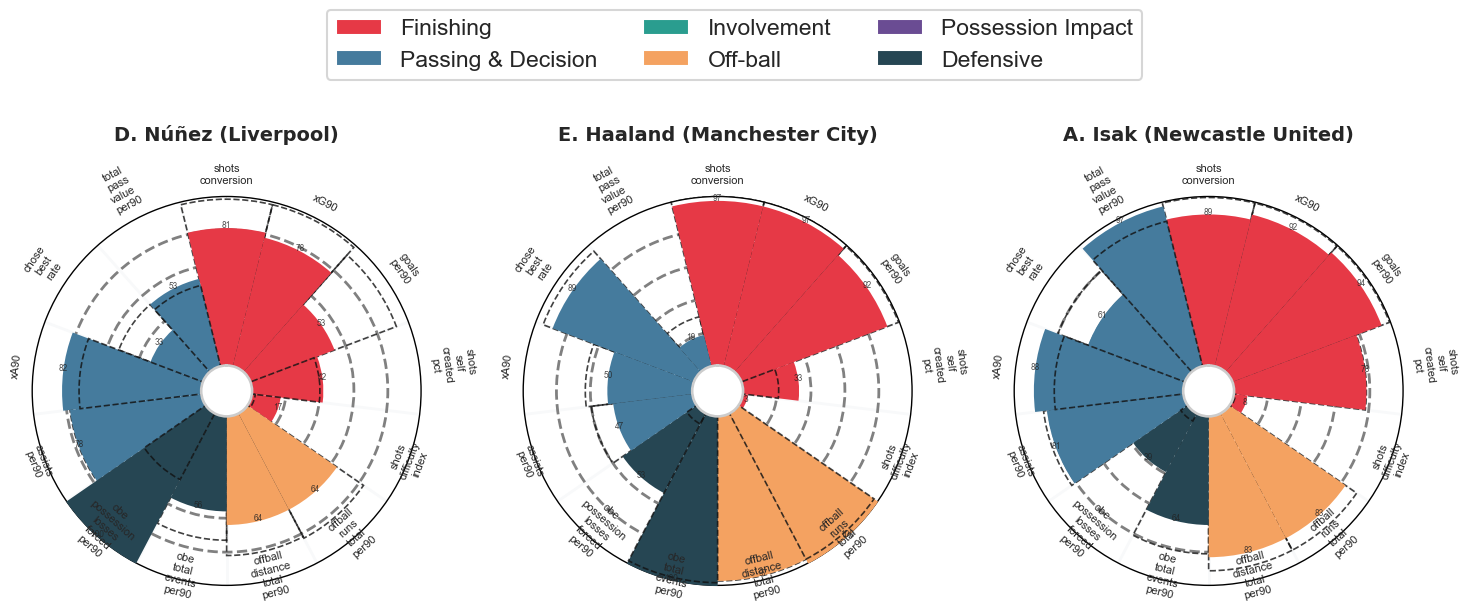

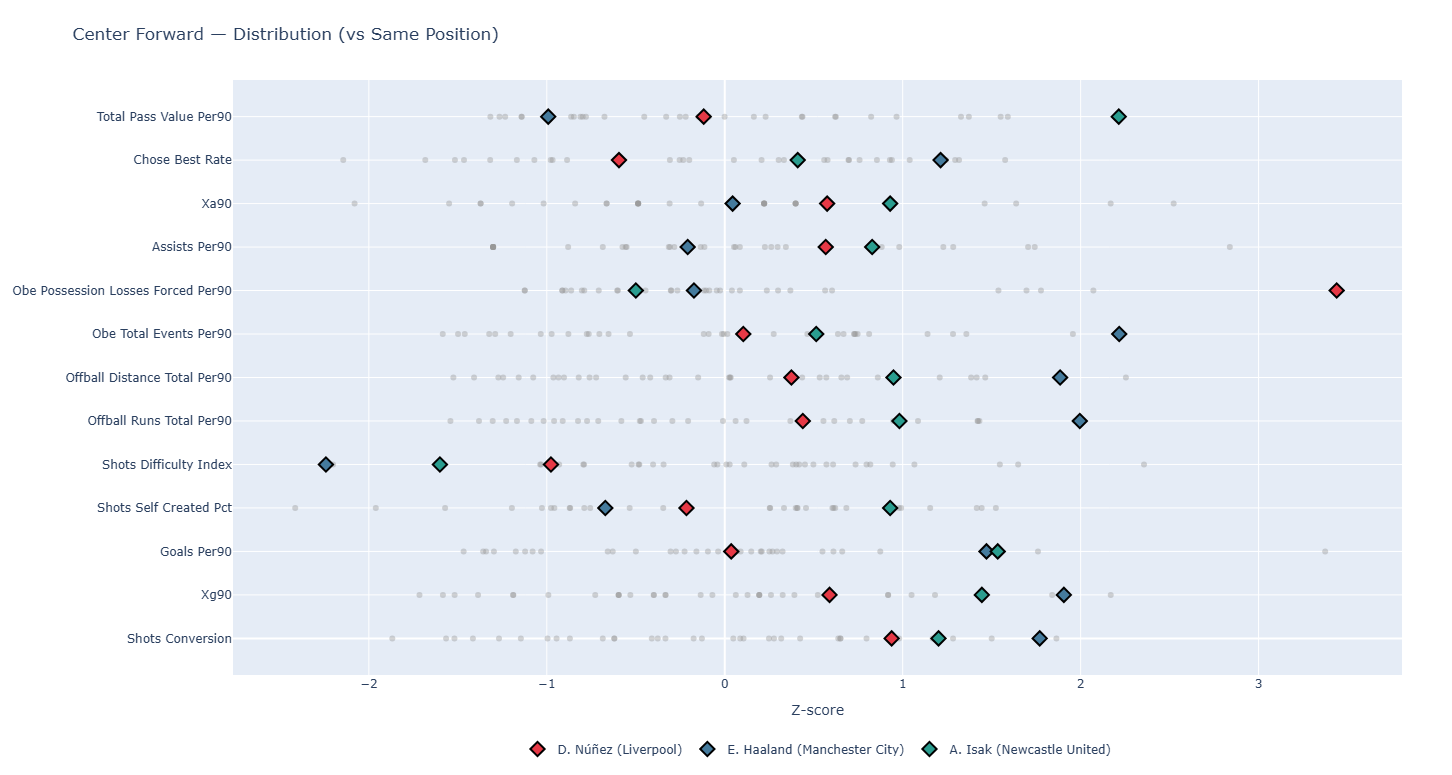

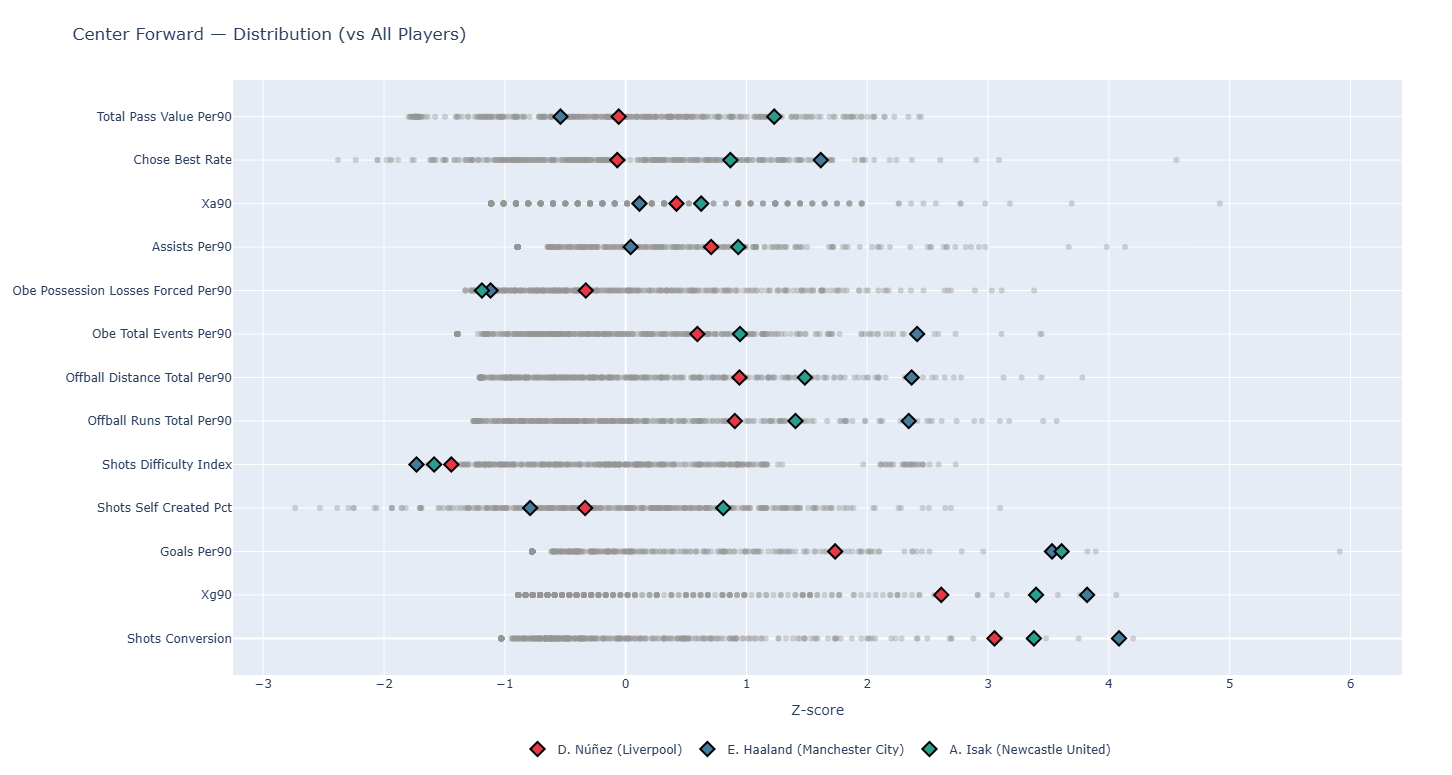

In [368]:
# USAGE EXAMPLE
plot_player_comparison(merged_final, ["D. Núñez", "E. Haaland", "A. Isak"])

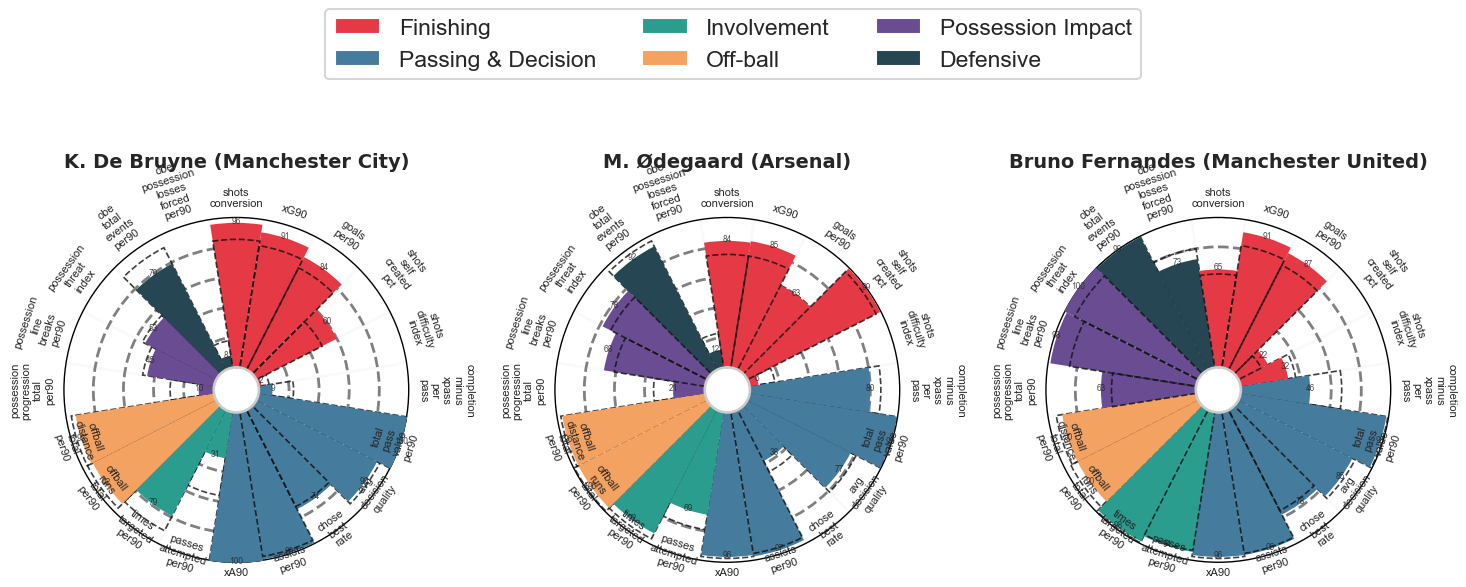

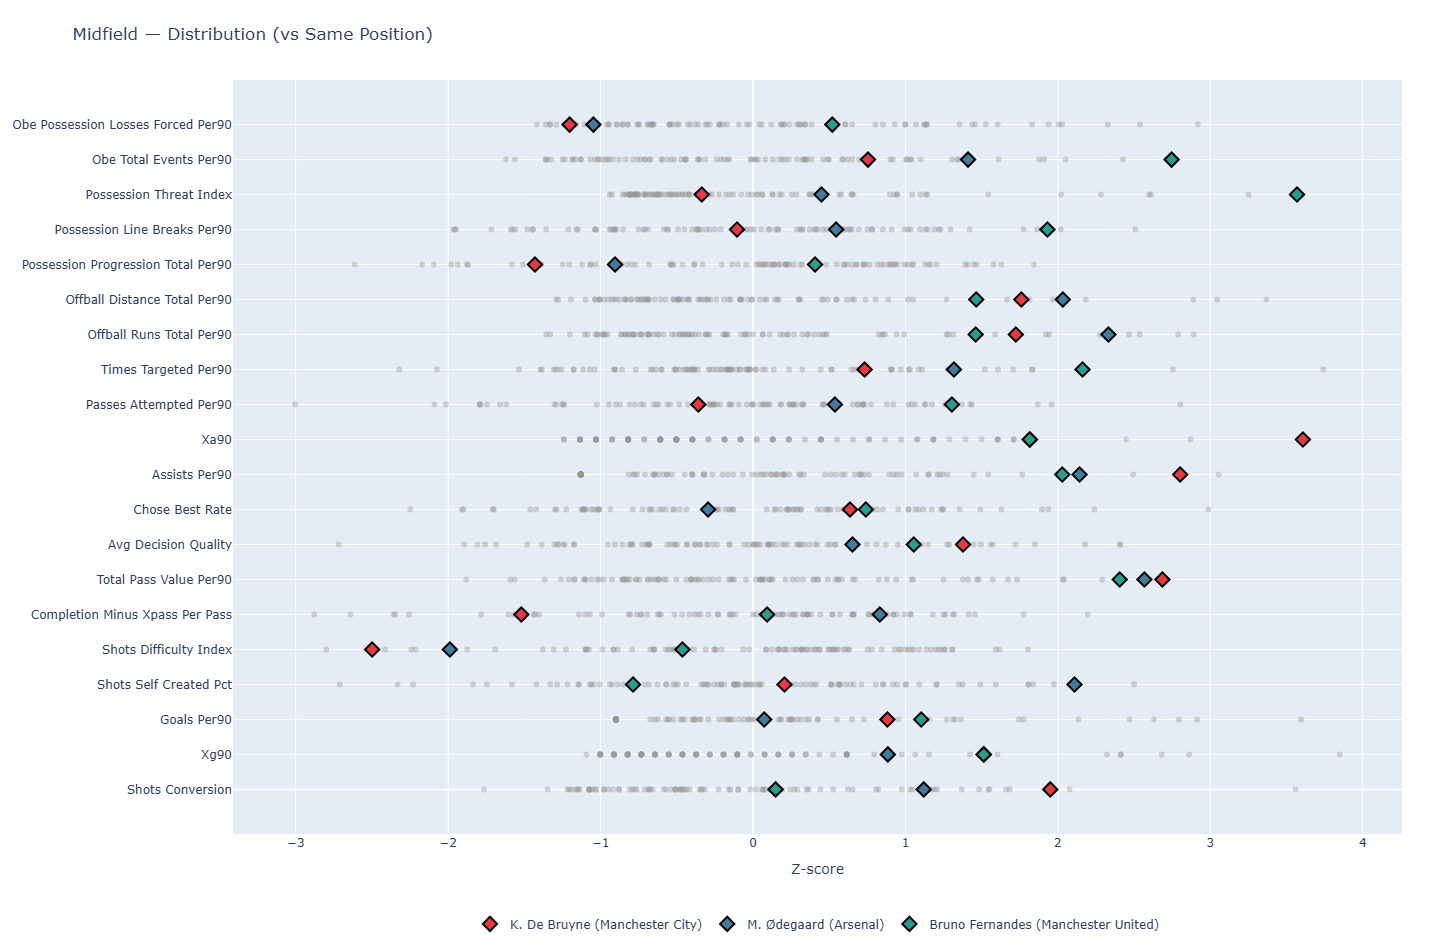

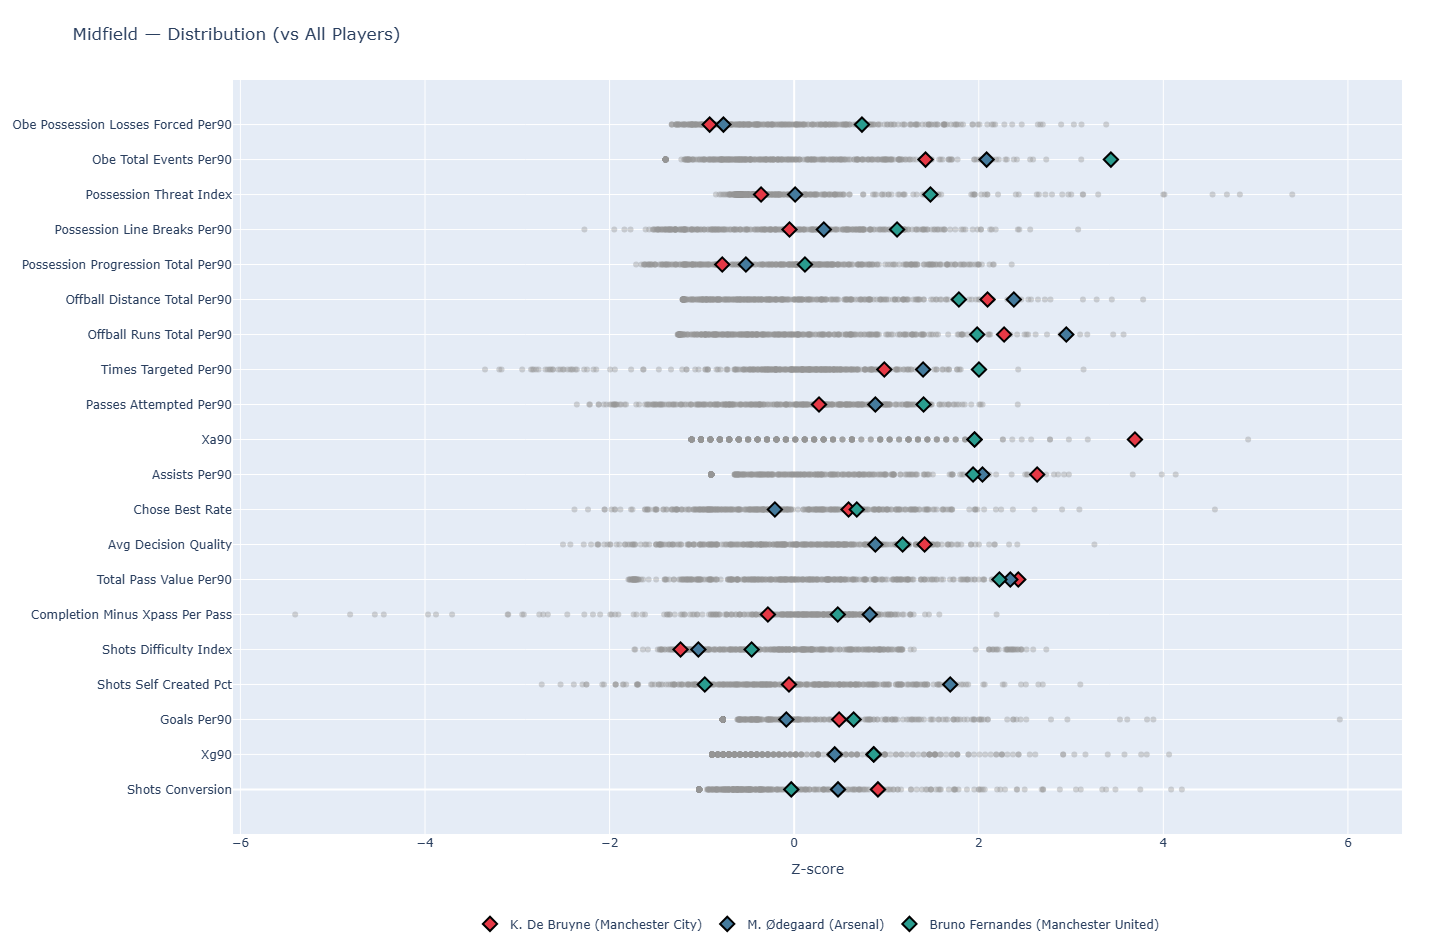

In [369]:
plot_player_comparison(merged_final, ["K. De Bruyne", "M. Ødegaard", "Bruno Fernandes"])